<a href="https://colab.research.google.com/github/abishaa242-ui/Anime-datase/blob/main/Anime%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:

from google.colab import files
uploaded = files.upload()

Saving anime_dataset.csv to anime_dataset.csv


Data Loading

This code loads the anime dataset using pandas and displays the first few rows to understand it's structure and contents

In [ ]:
import pandas as pd

df = pd.read_csv("anime_dataset.csv")
df.head()

,mal_id,title,title_english,title_japanese,type,source,episodes,status,airing,aired_from,...,season,year,studios,producers,licensors,genres,themes,demographics,synopsis,image_url
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN,"Crime is timeless. By the year 2071, humanity ...",https://myanimelist.net/images/anime/4/19644.jpg
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,Original,1.0,Finished Airing,False,2001-09-01,...,NaN,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NaN,"Another day, another bounty—such is the life o...",https://myanimelist.net/images/anime/1439/9348...
2,6,Trigun,Trigun,トライガン,TV,Manga,26.0,Finished Airing,False,1998-04-01,...,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen,"Vash the Stampede is the man with a $$60,000,0...",https://myanimelist.net/images/anime/1130/1200...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NaN,"Though hidden away from the general public, Wi...",https://myanimelist.net/images/anime/10/19969.jpg
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NaN,Shounen,It is the dark century and the people are suff...,https://myanimelist.net/images/anime/7/21569.jpg


In [ ]:
df.shape      # rows and columns

(30075, 29)

In [ ]:
df.columns    # column names

Index(['mal_id', 'title', 'title_english', 'title_japanese', 'type', 'source',
       'episodes', 'status', 'airing', 'aired_from', 'aired_to', 'duration',
       'rating', 'score', 'scored_by', 'rank', 'popularity', 'members',
       'favorites', 'season', 'year', 'studios', 'producers', 'licensors',
       'genres', 'themes', 'demographics', 'synopsis', 'image_url'],
      dtype='object')

In [ ]:
df.info()     # data types + missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30075 entries, 0 to 30074
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mal_id          30075 non-null  int64  
 1   title           30075 non-null  object 
 2   title_english   13306 non-null  object 
 3   title_japanese  29951 non-null  object 
 4   type            30003 non-null  object 
 5   source          30075 non-null  object 
 6   episodes        29236 non-null  float64
 7   status          30075 non-null  object 
 8   airing          30075 non-null  bool   
 9   aired_from      29166 non-null  object 
 10  aired_to        11594 non-null  object 
 11  duration        30075 non-null  object 
 12  rating          29473 non-null  object 
 13  score           19892 non-null  float64
 14  scored_by       19892 non-null  float64
 15  rank            22584 non-null  float64
 16  popularity      30075 non-null  int64  
 17  members         30075 non-null 

In [ ]:
df.describe() # statistical summary

,mal_id,episodes,score,scored_by,rank,popularity,members,favorites,year
count,30075.000000,29236.000000,19892.00000,1.989200e+04,22584.000000,30075.000000,3.007500e+04,30075.000000,6525.000000
mean,35019.558537,13.958886,6.42559,2.969837e+04,11275.337894,14957.319501,3.901396e+04,429.132801,2010.646130
std,19983.466507,47.334180,0.89078,1.225328e+05,6508.725236,8634.251988,1.693139e+05,4550.008408,13.294049
min,1.000000,1.000000,1.89000,1.010000e+02,1.000000,1.000000,0.000000e+00,0.000000,1961.000000
25%,16833.000000,1.000000,5.80000,3.180000e+02,5636.750000,7483.000000,2.430000e+02,0.000000,2005.000000
50%,38852.000000,2.000000,6.41000,1.456000e+03,11275.000000,14946.000000,1.088000e+03,1.000000,2014.000000
75%,52131.500000,13.000000,7.07000,9.676250e+03,16909.250000,22428.000000,9.307500e+03,17.000000,2021.000000
max,64012.000000,3000.000000,9.27000,3.060289e+06,22548.000000,29935.000000,4.348557e+06,251194.000000,2027.000000


Linear regression model for anime score prediction

Mean Absolute Error: 0.09728159458871902
R2 Score: 0.9569935686966209


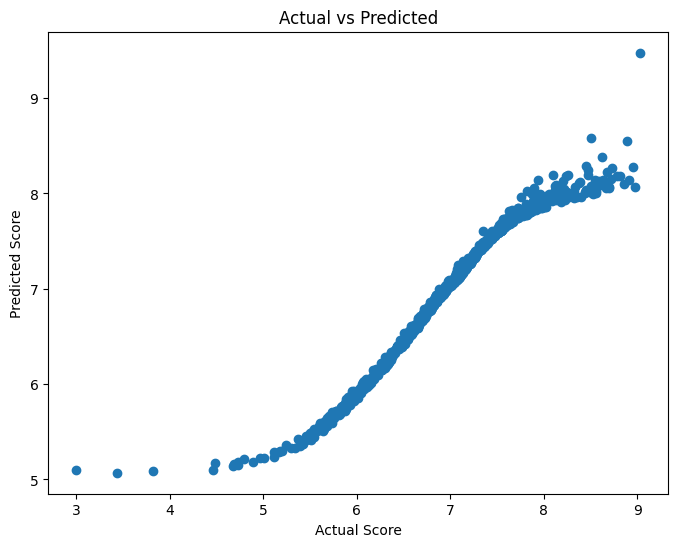

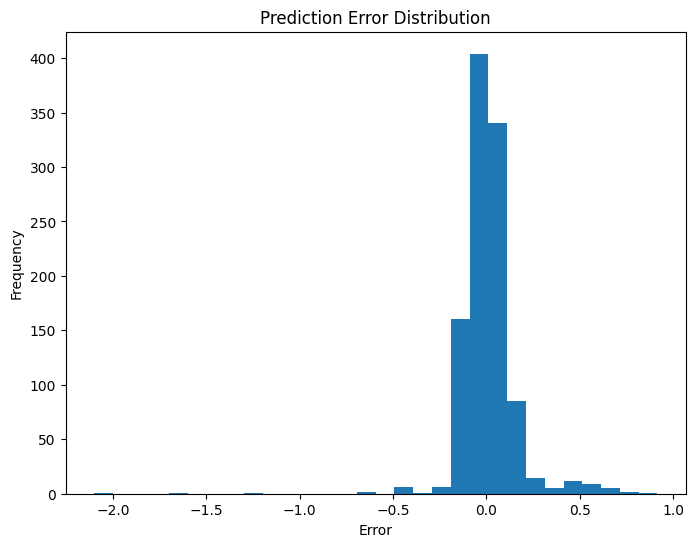

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


# Load dataset
df = pd.read_csv("anime_dataset.csv")

# Select numeric columns only
numeric_df = df.select_dtypes(include='number')

# Target column
target = "score"

# Check if target column exists
if target not in numeric_df.columns:
    raise ValueError(f"'{target}' column not found in dataset")

# Remove missing values
numeric_df = numeric_df.dropna()

# Check if data is empty
if numeric_df.empty:
    raise ValueError("Dataset is empty after removing missing values")

# Features and target
X = numeric_df.drop(columns=[target])
y = numeric_df[target]

# Check if feature columns exist
if X.shape[1] == 0:
    raise ValueError("No feature columns available for training")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict values
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


# Graph 1: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
plt.savefig("actual_vs_predicted.png")
plt.show()


# Graph 2: Prediction Error
errors = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30)
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.savefig("error_graph.png")
plt.show()

In [18]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9569935686966209


In [23]:
# Top 10 anime based on score
top_10 = df.sort_values(by="score", ascending=False).head(10)

print(top_10[["title", "score"]])

                                          title  score
23037                         Sousou no Frieren   9.27
28465  Steel Ball Run: JoJo no Kimyou na Bouken   9.15
3959           Fullmetal Alchemist: Brotherhood   9.11
25957              Chainsaw Man Movie: Reze-hen   9.08
5662                                Steins;Gate   9.07
14838        Shingeki no Kyojin Season 3 Part 2   9.05
15489                        Gintama: The Final   9.05
9871                                   Gintama°   9.05
6451                     Hunter x Hunter (2011)   9.03
5984                                   Gintama'   9.02


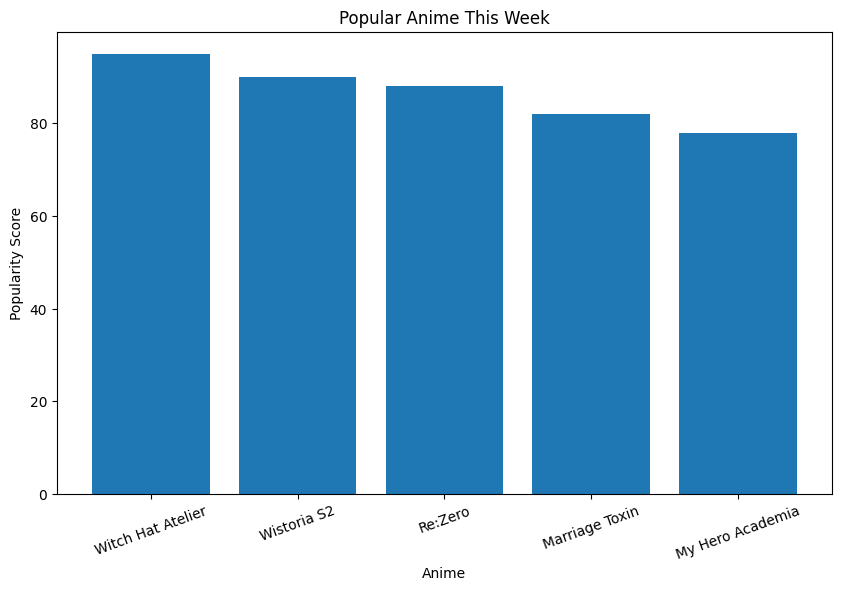

In [26]:
import matplotlib.pyplot as plt

# Sample weekly popularity data
anime_names = [
    "Witch Hat Atelier",
    "Wistoria S2",
    "Re:Zero",
    "Marriage Toxin",
    "My Hero Academia"
]

popularity = [95, 90, 88, 82, 78]


# Create bar graph
plt.figure(figsize=(10,6))
plt.bar(anime_names, popularity)

plt.xlabel("Anime")
plt.ylabel("Popularity Score")
plt.title("Popular Anime This Week")

plt.xticks(rotation=20)

# Save graph
plt.savefig("popular_anime_week.png")

plt.show()

Score Vs Popularity

In [30]:
# Select columns for comparison
score_popularity = df[["title", "score", "popularity"]]

# Show first 10 records
score_popularity_table = score_popularity.head(10)

print(score_popularity_table)

                             title  score  popularity
0                     Cowboy Bebop   8.75          41
1  Cowboy Bebop: Tengoku no Tobira   8.38         658
2                           Trigun   8.22         265
3               Witch Hunter Robin   7.25        1989
4                   Bouken Ou Beet   7.01        5891
5                     Eyeshield 21   7.92        1419
6             Hachimitsu to Clover   7.98         984
7       Hungry Heart: Wild Striker   7.59        4895
8           Initial D Fourth Stage   8.18        1300
9                          Monster   8.89         117


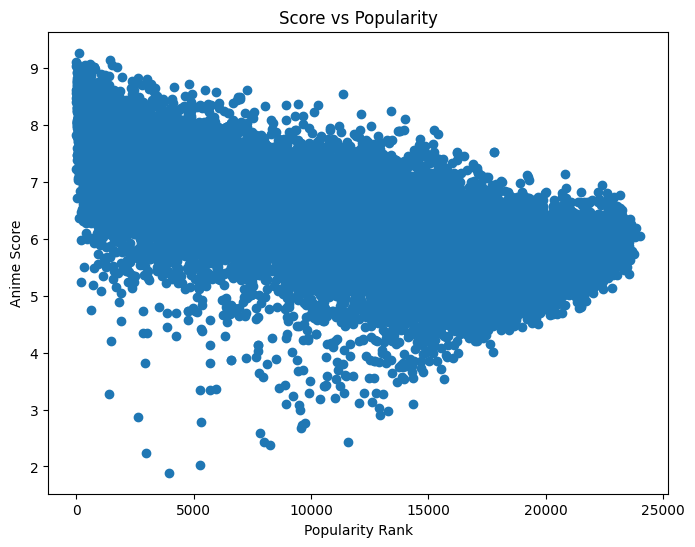

In [31]:
import matplotlib.pyplot as plt

# Remove missing values
graph_data = df[["score", "popularity"]].dropna()


# Create scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    graph_data["popularity"],
    graph_data["score"]
)

plt.xlabel("Popularity Rank")
plt.ylabel("Anime Score")
plt.title("Score vs Popularity")

# Save graph
plt.savefig("score_vs_popularity.png")

plt.show()